# Perseus tutorial

Perseus is a framework for working with heterogeneous sequences of user events. It scales to different
downstream tasks and supports cross-domain scenarios out of the box.

This tutorial shows how to solve all four tasks Perseus supports — retrieval, ranking, classification and
regression — on the small version of the [T-ECD](https://huggingface.co/datasets/t-tech/T-ECD) dataset.
Retrieval is the main use case, so we also use it to show how to add extra features, enrich the model with
events, and change architectural components — each time by editing a couple of
lines in the config.

Every task is compared against a baseline. 

## Perseus from an ML engineer's point of view

The ML engineer is responsible for two things: preparing the data in the format required by the task and
writing a YAML config with the model parameters. Everything else is done by the framework's commands.

Data comes in two kinds: **events** (the features) and the **basis** (the targets). The model consumes a
client's event history, turns it into a client embedding, and a head predicts the target on top of it. Every
event and every basis sample must have a `timestamp` and a `client_id`.

Training:

```bash
python -m perseus train prepare-dataset --workdir <train_workdir>   # build the dataset from the basis and the events
accelerate launch -m perseus train fit-model --workdir <train_workdir>   # train the model, result goes to checkpoint/
```

Inference:

```bash
python -m perseus inference distribute-samples --workdir <inference_workdir>        # split the basis into partitions
python -m perseus inference make-items-embeddings --workdir <inference_workdir>     # item embeddings (optional step)
python -m perseus inference make-backbone-embeddings --workdir <inference_workdir>  # client embeddings
python -m perseus inference make-head-predictions --workdir <inference_workdir>     # predictions, written to predictions/
```

Train and infrence workdirs are not obliged to be one and the same directory, though they may be. The ML engineer only prepares `basis/` and `config.yaml` for the train part and `basis/` and `checkpoint/` (copied after training) for the inference part; the rest of the working directory appears as the
commands are run:

```
workdir/
├── basis/                      # ML engineer
│   ├── train/                  #   training fold
│   │   ├── samples.pq          #     basis samples with targets
│   │   └── artifacts/items.pq  #     items and their features
│   ├── test/                   #   validation fold, same structure
│   │   ├── samples.pq
│   │   └── artifacts/items.pq
│   ├── samples.pq              #   basis for inference
│   └── artifacts/items.pq      #   items for inference
├── config.yaml                 # ML engineer
├── dataset/                    # Perseus, prepare-dataset: training dataset
├── checkpoint/                 # Perseus, prepare-dataset and fit-model: preprocessors, then model weights
├── samples/                    # Perseus, distribute-samples: inference basis split into partitions
├── embeddings/                 # Perseus, make-backbone-embeddings: client embeddings
├── items/                      # Perseus, make-items-embeddings: item embeddings
└── predictions/                # Perseus, make-head-predictions: final predictions
```

Artifacts (`artifacts/items.pq`) are only needed for retrieval and ranking; for classification and regression
the basis contains just `samples.pq`.

Perseus computes the metrics from the config itself, but only during training and only on the test fold.
Metrics at inference time, including the comparison against a baseline, are up to the ML engineer.

The notebook was run on a single H100; a linear run takes about 8 hours. Most cell outputs are preserved but the Perseus textual logs have been removed for brievity.

# Installation

Redirect the cache if needed. This is useful in a cloud environment with persistent storage, since the library
and its dependencies take about 5 GB.

In [1]:
import os

os.environ['UV_CACHE_DIR'] = '/tmp/uv_cache'

Install the framework as a library.

In [2]:
!rm -rf /tmp/perseus
!git clone https://github.com/perseus2026/perseus.git /tmp/perseus

Cloning into '/tmp/perseus'...
remote: Enumerating objects: 240, done.
remote: Counting objects: 100% (240/240), done.
remote: Compressing objects: 100% (179/179), done.
remote: Total 240 (delta 67), reused 225 (delta 59), pack-reused 0 (from 0)
Receiving objects: 100% (240/240), 177.58 KiB | 764.00 KiB/s, done.
Resolving deltas: 100% (67/67), done.


In [3]:
os.chdir("/tmp/perseus")

In [ ]:
!uv venv /tmp/perseus_venv
!source /tmp/perseus_venv/bin/activate && uv sync --no-dev

Also install the project in editable mode — we need it to call Perseus' metric code directly when comparing
against the baselines.

In [ ]:
!source /tmp/perseus_venv/bin/activate && pip install -e .

# Imports

In [6]:
import os
import subprocess
import tempfile
from datetime import timedelta
from getpass import getpass
from pathlib import Path
from warnings import filterwarnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from huggingface_hub import snapshot_download
from tqdm import tqdm

filterwarnings("ignore")

A thin wrapper over the Perseus API for computing metrics:

In [7]:
from perseus.core import tasks

def evaluate(
    task: str,
    samples: pl.DataFrame,
    metrics: dict[str, dict],
    artifacts: pl.DataFrame | None = None,
) -> dict[str, float]:
    entities = tasks.registry[task]
    name_to_metric = {
        name: entities.metrics[desc["type"]](**desc.get("params", {}))
        for name, desc in metrics.items()
    }
    artifacts = entities.artifacts() if artifacts is None else entities.artifacts(artifacts)
    evaluated = entities.evaluator(name_to_metric).calculate_metrics(samples, artifacts)
    return {name: groups["overall"] for name, groups in evaluated.items()}

The dataset is downloaded from HuggingFace, so an HF token is required.

In [8]:
os.environ["HF_TOKEN"] = getpass("HF_TOKEN:")

HF_TOKEN: ········


# Data

We work with the small version of T-ECD, domain Marketplace: four event types (view, click, like, clickout),
an item table with brand and price, and a user table with a socdem cluster. We also add the Retail and Offers domains.

In [9]:
download_dir = Path("../t_ecd/")

In [ ]:
snapshot_download(
    repo_id="t-tech/T-ECD",
    repo_type="dataset",
    allow_patterns="dataset/small/marketplace/",
    local_dir=download_dir
)

snapshot_download(
    repo_id="t-tech/T-ECD",
    repo_type="dataset",
    allow_patterns="dataset/small/users.pq",
    local_dir=download_dir
)

snapshot_download(
    repo_id="t-tech/T-ECD",
    repo_type="dataset",
    allow_patterns="dataset/small/retail/",
    local_dir=download_dir
)

snapshot_download(
    repo_id="t-tech/T-ECD",
    repo_type="dataset",
    allow_patterns="dataset/small/offers/",
    local_dir=download_dir
)

In [11]:
EVENTS = pl.read_parquet(download_dir / "dataset/small/marketplace/events")
EVENTS = EVENTS.select(
    pl.col("action_type").alias("event"),
    pl.col("timestamp").dt.total_microseconds().cast(pl.Datetime("us")).dt.truncate("1s").cast(pl.Datetime("ns")).alias("timestamp"),
    pl.col("user_id").cast(pl.String).alias("client_id"),
    "item_id",
    "subdomain",
).unique()

CLIENTS = pl.read_parquet(download_dir / "dataset/small/users.pq", columns=["user_id", "socdem_cluster"])
CLIENTS = CLIENTS.with_columns(pl.col("user_id").cast(pl.String).alias("client_id")).drop("user_id")

ITEMS = pl.read_parquet(download_dir / "dataset/small/marketplace/items.pq", columns=["item_id", "brand_id", "price"])

In [12]:
display(EVENTS.head(5))

event,timestamp,client_id,item_id,subdomain
str,datetime[ns],str,str,str
"""view""",1973-04-02 00:45:48,"""49831624""","""nfmcg_11789389""","""catalog"""
"""view""",1973-07-30 11:41:12,"""11221957""","""nfmcg_17866919""","""search"""
"""view""",1973-01-31 22:17:21,"""79982392""","""nfmcg_8556339""","""u2i"""
"""view""",1973-03-05 07:49:34,"""54008843""","""nfmcg_2942510""","""u2i"""
"""view""",1973-05-30 20:48:07,"""42292561""","""nfmcg_24719961""","""other"""


In [13]:
display(CLIENTS.head(5))

socdem_cluster,client_id
u8,str
21,"""77309558"""
10,"""72517894"""
9,"""86699708"""
17,"""54241043"""
17,"""23591057"""


In [14]:
display(ITEMS.head(5))

item_id,brand_id,price
str,u64,f64
"""nfmcg_10000001""",137356,6.06364
"""nfmcg_10000012""",53389,0.960436
"""nfmcg_1000002""",34153,-1.793113
"""nfmcg_10000034""",39543,3.416755
"""nfmcg_10000039""",82320,4.293433


In [15]:
retail_events = (
    pl.scan_parquet(download_dir / "dataset/small/retail/events")
    .filter(pl.col("action_type").eq("order"))
    .select(
        pl.col("action_type").alias("event"),
        pl.col("timestamp").dt.total_microseconds().cast(pl.Datetime("us")).dt.truncate("1s").cast(pl.Datetime("ns")).alias("timestamp"),
        pl.col("user_id").cast(pl.String).alias("client_id")
    ).unique()
).collect()

display(retail_events.head(5))

event,timestamp,client_id
str,datetime[ns],str
"""order""",1973-04-26 19:35:10,"""89502893"""
"""order""",1973-06-21 10:06:33,"""74410353"""
"""order""",1973-04-05 15:02:50,"""46724931"""
"""order""",1973-05-12 10:35:46,"""83733706"""
"""order""",1973-07-17 19:23:13,"""49090251"""


In [16]:
offers_events = (
    pl.scan_parquet(download_dir / "dataset/small/offers/events")
    .filter(~pl.col("action_type").eq("view"))
    .select(
        pl.col("action_type").alias("event"),
        pl.col("timestamp").dt.total_microseconds().cast(pl.Datetime("us")).dt.truncate("1s").cast(pl.Datetime("ns")).alias("timestamp"),
        pl.col("user_id").cast(pl.String).alias("client_id"),
        pl.col("item_id")
    ).unique()
    .join(
        pl.scan_parquet(download_dir / "dataset/small/offers/items.pq").select("item_id", "brand_id"), 
        on="item_id", 
        how="left"
    )
    .drop("item_id")
).collect()

display(offers_events.head(5))

event,timestamp,client_id,brand_id
str,datetime[ns],str,u64
"""clickout""",1973-06-10 00:22:48,"""68394813""",42730
"""click""",1973-07-13 09:14:06,"""88598591""",106481
"""click""",1973-02-19 05:02:35,"""54087573""",37799
"""click""",1973-05-06 11:22:28,"""17959115""",178484
"""click""",1973-06-10 20:35:13,"""43129806""",156793


The raw files can be removed from disk after loading — they take up a fair amount of space.

In [17]:
!rm -rf "../t_ecd/"

## Event Hub

The event store is called the **Event Hub**. Here it is a local directory whose path is given in an env file.
Every event must contain `timestamp` (ns) and `client_id` (string); everything else is optional attributes that
can later be used as features — for Marketplace those are `item_id` and `subdomain`.

In [18]:
!echo 'INTERNAL_STORAGE_EVENT_HUB=/event-hub/' > .env

Each event type is loaded by a separate command under its own name, so the Event Hub ends up with
`marketplace-view`, `marketplace-click`, `marketplace-like` and `marketplace-clickout`.

In [ ]:
env = {**os.environ, "INTERNAL_STORAGE_EVENT_HUB": "/event-hub/"}

for (event,), group in EVENTS.group_by("event"):
    event_name = f"marketplace-{event}"
    group = group.drop("event")

    with tempfile.TemporaryDirectory() as tmp:
        staging = Path(tmp) / "events.pq"
        group.write_parquet(staging)
        subprocess.run(
            [
                "uv", "run", "python", "-m", "perseus", 
                "event-hub", "add-events", 
                str(staging), 
                "--name", event_name, 
                "--source", "event_hub"
            ],
            env=env,
            check=True
        )

The framework fills in the event date itself — it uses it for internal partitioning.

In [20]:
display(pl.scan_parquet("/event-hub/marketplace-click/1972-12-18/0001.pq").head(5).collect())

timestamp,client_id,item_id,subdomain,date
datetime[ns],str,str,str,date
1972-12-18 00:35:45,"""26305974""","""nfmcg_3406439""","""u2i""",1972-12-18
1972-12-18 00:59:27,"""26305974""","""nfmcg_19742246""","""u2i""",1972-12-18
1972-12-18 01:22:05,"""53720163""","""nfmcg_15432422""","""i2i""",1972-12-18
1972-12-18 01:34:33,"""12895674""","""nfmcg_13757063""","""catalog""",1972-12-18
1972-12-18 02:28:29,"""8451192""","""nfmcg_2992071""","""u2i""",1972-12-18


And now we add Offers and Retail events.

In [ ]:
for (event,), group in retail_events.group_by("event"):
    event_name = f"retail-{event}"
    group = group.drop("event")

    with tempfile.TemporaryDirectory() as tmp:
        staging = Path(tmp) / "events.pq"
        group.write_parquet(staging)
        subprocess.run(
            [
                "uv", "run", "python", "-m", "perseus", 
                "event-hub", "add-events", 
                str(staging), 
                "--name", event_name, 
                "--source", "event_hub"
            ],
            env=env,
            check=True
        )

for (event,), group in offers_events.group_by("event"):
    event_name = f"offers-{event}"
    group = group.drop("event")

    with tempfile.TemporaryDirectory() as tmp:
        staging = Path(tmp) / "events.pq"
        group.write_parquet(staging)
        subprocess.run(
            [
                "uv", "run", "python", "-m", "perseus", 
                "event-hub", "add-events", 
                str(staging), 
                "--name", event_name, 
                "--source", "event_hub"
            ],
            env=env,
            check=True
        )

In [24]:
!ls /event-hub/

marketplace-click
marketplace-clickout
marketplace-like
marketplace-view
offers-click
offers-clickout
offers-like
retail-order


The client's socdem cluster and the item features do not go into the Event Hub: the first goes into the basis
context, the second into the artifacts.

# Retrieval

We predict which items a user is most likely to click on in Marketplace the next day. The metrics are
`Recall@100`, `NDCG@100` and `Coverage@100`.

In [36]:
RETRIEVAL_METRICS = {
    "recall@100": {"type": "recall_at_k", "params": {"k": 100}},
    "ndcg@100": {"type": "ndcg_at_k", "params": {"k": 100}},
    "coverage@100": {"type": "coverage_at_k", "params": {"k": 100}},
}
retrieval_evals = {}

A retrieval basis needs artifacts — an `items.pq` table with a mandatory `item` column; its other columns can
be used as item features. In `train/samples.pq` the target is the list of items the client interacted with in a
way that is useful for the business; negatives are generated by the framework during training. In
`test/samples.pq` every item in the target additionally carries a relevance, which is what the metrics are
computed from. The artifacts of each fold must contain every item appearing in that fold's target.

```
basis/
├── train/
│   ├── samples.pq
│   └── artifacts/
│       └── items.pq
└── test/
    ├── samples.pq
    └── artifacts/
        └── items.pq
```

## Basis

We build the basis from click events over the last 120 days. The timestamp is rounded to the date and shifted
by −12 hours ([a T-ECD constraint](https://huggingface.co/datasets/t-tech/T-ECD#⚠%EF%B8%8F-important-note-on-temporal-data-usage)).
A sample's target is every item the client clicked on that day. The basis is split into train and test 80/20 by
time.

In [22]:
os.makedirs("../retrieval/basis/train/artifacts/", exist_ok=True)
os.makedirs("../retrieval/basis/test/artifacts/", exist_ok=True)
os.makedirs("../retrieval/basis/artifacts/", exist_ok=True)

In [23]:
samples = pl.read_parquet("/event-hub/marketplace-click")
start_date = samples["date"].max() - timedelta(days=120)
samples = (
    samples
    .filter(pl.col("timestamp") >= start_date)
    .with_columns((pl.col("date").cast(pl.Datetime) - timedelta(hours=12)).cast(pl.Datetime("ns")).alias("timestamp"))
    .drop("date")
    .group_by("timestamp", "client_id").agg(pl.col("item_id").unique().alias("target"))
    .sort("timestamp")
)

print(samples.shape)
display(samples.head(5))

(776449, 3)


timestamp,client_id,target
datetime[ns],str,list[str]
1973-04-02 12:00:00,"""9378515""","[""nfmcg_22222683"", ""nfmcg_12968689""]"
1973-04-02 12:00:00,"""56805702""","[""nfmcg_18905990""]"
1973-04-02 12:00:00,"""37362658""","[""nfmcg_16626223""]"
1973-04-02 12:00:00,"""71283663""","[""nfmcg_21339836"", ""nfmcg_26099247"", ""nfmcg_18347755""]"
1973-04-02 12:00:00,"""63483019""","[""nfmcg_10973428""]"


In [24]:
train_ratio = 0.8
split_idx = int(len(samples) * train_ratio)
split_timestamp = samples["timestamp"][split_idx]

In [25]:
train_samples = samples.filter(pl.col("timestamp") < split_timestamp)

print(train_samples.shape)
display(train_samples.head(5))

(615222, 3)


timestamp,client_id,target
datetime[ns],str,list[str]
1973-04-02 12:00:00,"""9378515""","[""nfmcg_22222683"", ""nfmcg_12968689""]"
1973-04-02 12:00:00,"""56805702""","[""nfmcg_18905990""]"
1973-04-02 12:00:00,"""37362658""","[""nfmcg_16626223""]"
1973-04-02 12:00:00,"""71283663""","[""nfmcg_21339836"", ""nfmcg_26099247"", ""nfmcg_18347755""]"
1973-04-02 12:00:00,"""63483019""","[""nfmcg_10973428""]"


In [26]:
test_samples = samples.filter(pl.col("timestamp") >= split_timestamp)
test_samples = (
    test_samples
    .with_columns(
        pl.col("target").list.eval(
            pl.struct([
                pl.element().alias("item"),
                pl.lit(1).alias("relevance")
            ])
        ).alias("target")
    )
)

print(test_samples.shape)
display(test_samples.head(5))

(161227, 3)


timestamp,client_id,target
datetime[ns],str,list[struct[2]]
1973-07-01 12:00:00,"""31775866""","[{""nfmcg_19926411"",1}, {""nfmcg_14521559"",1}]"
1973-07-01 12:00:00,"""3039520""","[{""nfmcg_6782852"",1}, {""nfmcg_25274753"",1}]"
1973-07-01 12:00:00,"""55812184""","[{""nfmcg_19353812"",1}]"
1973-07-01 12:00:00,"""76012854""","[{""nfmcg_13647154"",1}]"
1973-07-01 12:00:00,"""22439851""","[{""nfmcg_6301488"",1}, {""nfmcg_5966104"",1}, … {""nfmcg_11782490"",1}]"


### Context

Context features are the ones that belong to the basis sample as a whole rather than to a single event. We put
the client's socdem cluster there.

In [27]:
train_samples = train_samples.join(CLIENTS, on="client_id", how="left")
train_samples = train_samples.with_columns(
    pl.struct(["socdem_cluster"]).alias("context")
).drop(["socdem_cluster"])

print(train_samples.shape)
display(train_samples.head(5))

(615222, 4)


timestamp,client_id,target,context
datetime[ns],str,list[str],struct[1]
1973-04-02 12:00:00,"""9378515""","[""nfmcg_22222683"", ""nfmcg_12968689""]",{20}
1973-04-02 12:00:00,"""56805702""","[""nfmcg_18905990""]",{17}
1973-04-02 12:00:00,"""37362658""","[""nfmcg_16626223""]",{4}
1973-04-02 12:00:00,"""71283663""","[""nfmcg_21339836"", ""nfmcg_26099247"", ""nfmcg_18347755""]",{9}
1973-04-02 12:00:00,"""63483019""","[""nfmcg_10973428""]",{19}


In [28]:
test_samples = test_samples.join(CLIENTS, on="client_id", how="left")
test_samples = test_samples.with_columns(
    pl.struct(["socdem_cluster"]).alias("context")
).drop(["socdem_cluster"])

print(test_samples.shape)
display(test_samples.head(5))

(161227, 4)


timestamp,client_id,target,context
datetime[ns],str,list[struct[2]],struct[1]
1973-07-01 12:00:00,"""31775866""","[{""nfmcg_19926411"",1}, {""nfmcg_14521559"",1}]",{9}
1973-07-01 12:00:00,"""3039520""","[{""nfmcg_6782852"",1}, {""nfmcg_25274753"",1}]",{20}
1973-07-01 12:00:00,"""55812184""","[{""nfmcg_19353812"",1}]",{21}
1973-07-01 12:00:00,"""76012854""","[{""nfmcg_13647154"",1}]",{0}
1973-07-01 12:00:00,"""22439851""","[{""nfmcg_6301488"",1}, {""nfmcg_5966104"",1}, … {""nfmcg_11782490"",1}]",{9}


#### Save

In [29]:
train_samples.write_parquet("../retrieval/basis/train/samples.pq")
test_samples.write_parquet("../retrieval/basis/test/samples.pq")

### Artifacts

The artifacts hold the items from the train part of the basis together with their brand. The test artifacts
duplicate the training ones: the model is tied to the item id and cannot recommend anything it has not seen
during training.

In [30]:
artifacts = pl.DataFrame(train_samples["target"].explode().unique())
artifacts = artifacts.join(ITEMS, left_on="target", right_on="item_id", how="left").rename({"target": "item"}).select("item", "brand_id")

print(artifacts.shape)
display(artifacts.head(5))

(196329, 2)


item,brand_id
str,u64
"""nfmcg_11867083""",139689
"""nfmcg_24425612""",135982
"""nfmcg_825239""",158061
"""nfmcg_2024090""",211031
"""nfmcg_5179763""",183492


#### Save

In [31]:
artifacts.write_parquet("../retrieval/basis/train/artifacts/items.pq")
artifacts.write_parquet("../retrieval/basis/test/artifacts/items.pq")

### Inference basis

The inference basis is a copy of the test fold, artifacts included. We prepare it once, before the baseline and
before the first training run: the basis then stays fixed, so the metrics of every model variant remain
comparable with each other and with the baseline.

The target is not required for inference itself, but we need it to compute the metrics.

In [32]:
inference_basis = pl.read_parquet("../retrieval/basis/test/samples.pq")

print(inference_basis.shape)
display(inference_basis.head(5))

inference_basis.write_parquet("../retrieval/basis/samples.pq")

(161227, 4)


timestamp,client_id,target,context
datetime[ns],str,list[struct[2]],struct[1]
1973-07-01 12:00:00,"""31775866""","[{""nfmcg_19926411"",1}, {""nfmcg_14521559"",1}]",{9}
1973-07-01 12:00:00,"""3039520""","[{""nfmcg_6782852"",1}, {""nfmcg_25274753"",1}]",{20}
1973-07-01 12:00:00,"""55812184""","[{""nfmcg_19353812"",1}]",{21}
1973-07-01 12:00:00,"""76012854""","[{""nfmcg_13647154"",1}]",{0}
1973-07-01 12:00:00,"""22439851""","[{""nfmcg_6301488"",1}, {""nfmcg_5966104"",1}, … {""nfmcg_11782490"",1}]",{9}


In [33]:
inference_artifacts = pl.read_parquet("../retrieval/basis/test/artifacts/items.pq")

print(inference_artifacts.shape)
display(inference_artifacts.head(5))

inference_artifacts.write_parquet("../retrieval/basis/artifacts/items.pq")

(196329, 2)


item,brand_id
str,u64
"""nfmcg_11867083""",139689
"""nfmcg_24425612""",135982
"""nfmcg_825239""",158061
"""nfmcg_2024090""",211031
"""nfmcg_5179763""",183492


Splitting the basis into partitions is also done once. The command is especially useful when several inference
processes are run in parallel: each of them scores its own part of the basis.

In [34]:
!uv run python -m perseus inference distribute-samples --workdir ../retrieval

2026-08-20T07:20:50.379310Z [info     ] has 161227 samples for 100 partitions [perseus.api.distribute_samples]


## Baseline

As a baseline we take the top-100 most popular items from the train part of the basis and recommend them to
every user. An item's score is its position in the top, so the order inside the recommendations is defined too.

**Note:** the baseline is computed **before** training the model, on the full inference basis. At inference the
framework drops samples of clients that have no event earlier than the sample timestamp, so `predictions/`
usually has fewer rows than the basis. We therefore join the model predictions onto the full basis and fill the
gaps with the baseline — both estimates then live on the same set of samples. We do the same in every task
below.

In [38]:
toppop_items = (
    train_samples.explode("target")["target"]
    .value_counts().sort("count", descending=True).head(100)["target"].to_list()
)
toppop_prediction = [
    {"item": item, "score": float(len(toppop_items) - rank)}
    for rank, item in enumerate(toppop_items)
]

In [40]:
inference_basis = pl.read_parquet("../retrieval/basis/samples.pq")
inference_artifacts = pl.read_parquet("../retrieval/basis/artifacts/items.pq")

In [42]:
retrieval_evals["baseline"] = evaluate(
    "retrieval",
    inference_basis.with_columns(prediction=pl.Series("prediction", [toppop_prediction] * len(inference_basis))),
    RETRIEVAL_METRICS,
    artifacts=inference_artifacts,
)
retrieval_evals["baseline"]

{'recall@100': 0.1275257170200348,
 'ndcg@100': 0.042984187602996826,
 'coverage@100': 0.0005093491027815555}

## Training

### Base

The first model uses a single feature — the sequence of `item_id`. The config describes the task and its
metrics, the target event, the item encoder, the backbone (a 4-layer ModernBERT with sum as the event
aggregator) and the training and inference parameters.

In [43]:
%%writefile ../retrieval/config.yaml
task:
  type: retrieval
  metrics:
    recall@100:
      type: recall_at_k
      params:
        k: 100
    ndcg@100:
      type: ndcg_at_k
      params:
        k: 100
    coverage@100:
      type: coverage_at_k
      params:
        k: 100

events:
  marketplace-click:
    attributes:
      item_id:
    max_duration_per_sequence: 365d
max_events_per_sequence: 512

encoders:
  item:
    type: id

features:
  item_id:
    located_in:
      event: true
    encoder: item
  item:
    located_in:
      artifacts: true
    encoder: item

backbone:
  dim: 256
  history_aggregator:
    type: modern_bert
    params:
      num_layers: 4
      num_heads: 4
      dropout: 0.1
  event_aggregator:
    type: sum

training:
  num_epochs: 10
  log_every_n_train_steps: 1000
  dataloader:
    batch_size: 32
    num_workers: 2
    pin_memory: true
    shuffle: true
  test_dataloader:
    batch_size: 32
    num_workers: 2
    pin_memory: true
  early_stopping:
    metric: recall@100
    mode: max
    patience: 3
  optimizer:
    params:
      lr: 0.0003

inference:
  backbone_dataloader:
    batch_size: 64
    num_workers: 0
    pin_memory: true
  head_dataloader:
    batch_size: 64
    num_workers: 0
    pin_memory: true
  predict_kwargs:
    k: 1000

Writing ../retrieval/config.yaml


Two commands are enough: build the dataset and train the model. The whole training process is documented
automatically as text logs.

In [ ]:
!uv run python -m perseus train prepare-dataset --workdir ../retrieval

In [ ]:
!uv run accelerate launch -m perseus train fit-model --workdir ../retrieval

Inference is no harder — run the model and compute the same metrics we computed for the baseline. It works
this way throughout: every model variant is inferred right after training, while its checkpoint is still in the
workdir.

In [ ]:
!uv run python -m perseus inference make-backbone-embeddings --workdir ../retrieval
!uv run python -m perseus inference make-head-predictions --workdir ../retrieval

In [52]:
predictions = pl.read_parquet("../retrieval/predictions").drop("_index")

retrieval_evals["base"] = evaluate(
    "retrieval",
    inference_basis.join(
        predictions, on=["client_id", "timestamp"], how="left"
    ).with_columns(
        pl.col("prediction").fill_null(toppop_prediction)
    ),
    RETRIEVAL_METRICS,
    artifacts=inference_artifacts,
)
retrieval_evals["base"]

{'recall@100': 0.15180166065692902,
 'ndcg@100': 0.05445351079106331,
 'coverage@100': 0.005572279184430217}

A separate command produces item embeddings. They can be useful, for example, to look up similar items or as
features in another model.

In [ ]:
!uv run python -m perseus inference make-items-embeddings --workdir ../retrieval

In [54]:
item_embeddings = pl.read_parquet("../retrieval/items/embeddings.pq")

print(item_embeddings.shape)
display(item_embeddings.sample(5))

(196329, 2)


item,embeddings
str,"array[f32, 256]"
"""nfmcg_14225762""","[-0.6562, 1.117221, … -0.894723]"
"""nfmcg_24393555""","[-0.097184, 0.16882, … -0.573923]"
"""nfmcg_21653171""","[-0.070593, 0.249302, … -0.547055]"
"""nfmcg_27642537""","[-0.28213, 0.259442, … -1.551369]"
"""nfmcg_26205231""","[-0.065248, 0.625412, … -1.123875]"


### + Features

Marketplace has more than just `item_id`. We add the service subdomain from the events, the item brand from the
artifacts and the client's socdem cluster from the context. No new data preparation is needed — all of it was
already stored when we built the Event Hub and the basis, so it is enough to list the features in the config,
stating for each one where it lives (`located_in`) and which encoder is used.

In [56]:
%%writefile ../retrieval/config.yaml
task:
  type: retrieval
  metrics:
    recall@100:
      type: recall_at_k
      params:
        k: 100
    ndcg@100:
      type: ndcg_at_k
      params:
        k: 100
    coverage@100:
      type: coverage_at_k
      params:
        k: 100

events:
  marketplace-click:
    attributes:
      item_id:
      subdomain:
    max_duration_per_sequence: 365d
max_events_per_sequence: 512

encoders:
  item:
    type: id
  subdomain:
    type: id
  brand_id:
    type: id
  socdem_cluster:
    type: id

features:
  item_id:
    located_in:
      event: true
    encoder: item
  item:
    located_in:
      artifacts: true
    encoder: item
  subdomain:
    located_in:
      event: true
    encoder: subdomain
  brand_id:
    located_in:
      artifacts: true
    encoder: brand_id
  socdem_cluster:
    located_in:
      context: true
    encoder: socdem_cluster
  
backbone:
  dim: 256
  history_aggregator:
    type: modern_bert
    params:
      num_layers: 4
      num_heads: 4
      dropout: 0.1
  event_aggregator:
    type: sum
  context_aggregator:
    type: identity

training:
  num_epochs: 10
  log_every_n_train_steps: 1000
  dataloader:
    batch_size: 32
    num_workers: 2
    pin_memory: true
    shuffle: true
  test_dataloader:
    batch_size: 32
    num_workers: 2
    pin_memory: true
  early_stopping:
    metric: recall@100
    mode: max
    patience: 3
  optimizer:
    params:
      lr: 0.0003
      
inference:
  backbone_dataloader:
    batch_size: 64
    num_workers: 0
    pin_memory: true
  head_dataloader:
    batch_size: 64
    num_workers: 0
    pin_memory: true
  predict_kwargs:
    k: 1000

Overwriting ../retrieval/config.yaml


Rebuild the dataset and train the model.

In [ ]:
!uv run python -m perseus train prepare-dataset --workdir ../retrieval

In [ ]:
!uv run accelerate launch -m perseus train fit-model --workdir ../retrieval

Inference and metrics again.

In [ ]:
!uv run python -m perseus inference make-backbone-embeddings --workdir ../retrieval
!uv run python -m perseus inference make-head-predictions --workdir ../retrieval

In [60]:
predictions = pl.read_parquet("../retrieval/predictions").drop("_index")
retrieval_evals["+ features"] = evaluate(
    "retrieval",
    inference_basis.join(
        predictions, on=["client_id", "timestamp"], how="left"
    ).with_columns(
        pl.col("prediction").fill_null(toppop_prediction)
    ),
    RETRIEVAL_METRICS,
    artifacts=inference_artifacts,
)
retrieval_evals["+ features"]

{'recall@100': 0.1553143709897995,
 'ndcg@100': 0.05724719911813736,
 'coverage@100': 0.009850811647795282}

### + Events

Now we enrich the model with events. On top of clicks we add Marketplace likes and clickouts, plus events from
neighbouring domains — orders in Retail and clicks, likes and clickouts in Offers.

Two things are worth noting here. First, Offers events have no `item_id` but do have a brand — the same feature
as in the Marketplace artifacts, so we encode it with a shared encoder and information from the other domain
lands in the same space. Second, there are now many more events while the history length is bounded, so we give
the target event a higher priority (by default every event has priority 0) — otherwise item clicks would be
pushed out of the sequence by the rest.

In [67]:
%%writefile ../retrieval/config.yaml
task:
  type: retrieval
  metrics:
    recall@100:
      type: recall_at_k
      params:
        k: 100
    ndcg@100:
      type: ndcg_at_k
      params:
        k: 100
    coverage@100:
      type: coverage_at_k
      params:
        k: 100

events:
  marketplace-click:
    attributes:
      item_id:
      subdomain:
    max_duration_per_sequence: 365d
    priority: 2
  marketplace-like:
    attributes:
      item_id:
      subdomain:
    max_duration_per_sequence: 365d
    priority: 1
  marketplace-clickout:
    attributes:
      item_id:
      subdomain:
    max_duration_per_sequence: 365d
    priority: 1
  retail-order:
    max_duration_per_sequence: 365d
  offers-click:
    attributes:
      brand_id:
    max_duration_per_sequence: 365d
  offers-like:
    attributes:
      brand_id:
    max_duration_per_sequence: 365d
  offers-clickout:
    attributes:
      brand_id:
    max_duration_per_sequence: 365d
max_events_per_sequence: 512

encoders:
  item:
    type: id
  subdomain:
    type: id
  brand_id:
    type: id
  socdem_cluster:
    type: id

features:
  item_id:
    located_in:
      event: true
    encoder: item
  item:
    located_in:
      artifacts: true
    encoder: item
  subdomain:
    located_in:
      event: true
    encoder: subdomain
  brand_id:
    located_in:
      event: true
      artifacts: true
    encoder: brand_id
  socdem_cluster:
    located_in:
      context: true
    encoder: socdem_cluster

backbone:
  dim: 256
  history_aggregator:
    type: modern_bert
    params:
      num_layers: 4
      num_heads: 4
      dropout: 0.1
  event_aggregator:
    type: sum
  context_aggregator:
    type: identity

training:
  num_epochs: 10
  log_every_n_train_steps: 1000
  dataloader:
    batch_size: 32
    num_workers: 2
    pin_memory: true
    shuffle: true
  test_dataloader:
    batch_size: 32
    num_workers: 2
    pin_memory: true
  early_stopping:
    metric: recall@100
    mode: max
    patience: 3
  optimizer:
    params:
      lr: 0.0003

inference:
  backbone_dataloader:
    batch_size: 64
    num_workers: 0
    pin_memory: true
  head_dataloader:
    batch_size: 64
    num_workers: 0
    pin_memory: true
  predict_kwargs:
    k: 1000

Overwriting ../retrieval/config.yaml


In [ ]:
!uv run python -m perseus train prepare-dataset --workdir ../retrieval

In [ ]:
!uv run accelerate launch -m perseus train fit-model --workdir ../retrieval

Inference and metrics again.

In [ ]:
!uv run python -m perseus inference make-backbone-embeddings --workdir ../retrieval
!uv run python -m perseus inference make-head-predictions --workdir ../retrieval

In [71]:
predictions = pl.read_parquet("../retrieval/predictions").drop("_index")

retrieval_evals["+ events"] = evaluate(
    "retrieval",
    inference_basis.join(
        predictions, on=["client_id", "timestamp"], how="left"
    ).with_columns(
        pl.col("prediction").fill_null(toppop_prediction)
    ),
    RETRIEVAL_METRICS,
    artifacts=inference_artifacts,
)
retrieval_evals["+ events"]

{'recall@100': 0.163809671998024,
 'ndcg@100': 0.06342106312513351,
 'coverage@100': 0.00459432890708963}

### + Tuning

Finally we change the architecture: ModernBERT is replaced by HSTU (which accounts not only for the order of
events but also for the time between them), and the sum in the event aggregator becomes a weighted sum. A
couple of lines in the config is all it takes.

In [72]:
%%writefile ../retrieval/config.yaml
task:
  type: retrieval
  metrics:
    recall@100:
      type: recall_at_k
      params:
        k: 100
    ndcg@100:
      type: ndcg_at_k
      params:
        k: 100
    coverage@100:
      type: coverage_at_k
      params:
        k: 100

events:
  marketplace-click:
    attributes:
      item_id:
      subdomain:
    max_duration_per_sequence: 365d
    priority: 2
  marketplace-like:
    attributes:
      item_id:
      subdomain:
    max_duration_per_sequence: 365d
    priority: 1
  marketplace-clickout:
    attributes:
      item_id:
      subdomain:
    max_duration_per_sequence: 365d
    priority: 1
  retail-order:
    max_duration_per_sequence: 365d
  offers-click:
    attributes:
      brand_id:
    max_duration_per_sequence: 365d
  offers-like:
    attributes:
      brand_id:
    max_duration_per_sequence: 365d
  offers-clickout:
    attributes:
      brand_id:
    max_duration_per_sequence: 365d
max_events_per_sequence: 512

encoders:
  item:
    type: id
  subdomain:
    type: id
  brand_id:
    type: id
  socdem_cluster:
    type: id

features:
  item_id:
    located_in:
      event: true
    encoder: item
  item:
    located_in:
      artifacts: true
    encoder: item
  subdomain:
    located_in:
      event: true
    encoder: subdomain
  brand_id:
    located_in:
      event: true
      artifacts: true
    encoder: brand_id
  socdem_cluster:
    located_in:
      context: true
    encoder: socdem_cluster

backbone:
  dim: 256
  history_aggregator:
    type: hstu
    params:
      num_layers: 4
      num_heads: 4
      dropout: 0.1
  event_aggregator:
    type: weighted_sum
  context_aggregator:
    type: identity

training:
  num_epochs: 10
  log_every_n_train_steps: 1000
  dataloader:
    batch_size: 32
    num_workers: 2
    pin_memory: true
    shuffle: true
  test_dataloader:
    batch_size: 32
    num_workers: 2
    pin_memory: true
  early_stopping:
    metric: recall@100
    mode: max
    patience: 3
  optimizer:
    params:
      lr: 0.0003

inference:
  backbone_dataloader:
    batch_size: 64
    num_workers: 0
    pin_memory: true
  head_dataloader:
    batch_size: 64
    num_workers: 0
    pin_memory: true
  predict_kwargs:
    k: 1000

Overwriting ../retrieval/config.yaml


The data has not changed, so there is no need to rebuild the dataset — we go straight to training.

In [73]:
!cp ../retrieval/config.yaml ../retrieval/checkpoint/config.yaml

In [ ]:
!uv run accelerate launch -m perseus train fit-model --workdir ../retrieval

And inference one last time.

In [ ]:
!uv run python -m perseus inference make-backbone-embeddings --workdir ../retrieval
!uv run python -m perseus inference make-head-predictions --workdir ../retrieval

In [15]:
predictions = pl.read_parquet("../retrieval/predictions").drop("_index")
retrieval_evals["+ tuning"] = evaluate(
    "retrieval",
    inference_basis.join(
        predictions, on=["client_id", "timestamp"], how="left"
    ).with_columns(
        pl.col("prediction").fill_null(toppop_prediction)
    ),
    RETRIEVAL_METRICS,
    artifacts=inference_artifacts,
)
retrieval_evals["+ tuning"]

{'recall@100': 0.1811884194612503,
 'ndcg@100': 0.07052737474441528,
 'coverage@100': 0.05415909009876279}

### Comparison

In [17]:
display(pl.DataFrame([{"option": option} | metrics for option, metrics in retrieval_evals.items()]))

option,recall@100,ndcg@100,coverage@100
str,f64,f64,f64
"""baseline""",0.127526,0.042984,0.000509
"""base""",0.151802,0.054454,0.005572
"""+ features""",0.155314,0.057247,0.009851
"""+ events""",0.16381,0.063421,0.004594
"""+ tuning""",0.181188,0.070527,0.054159


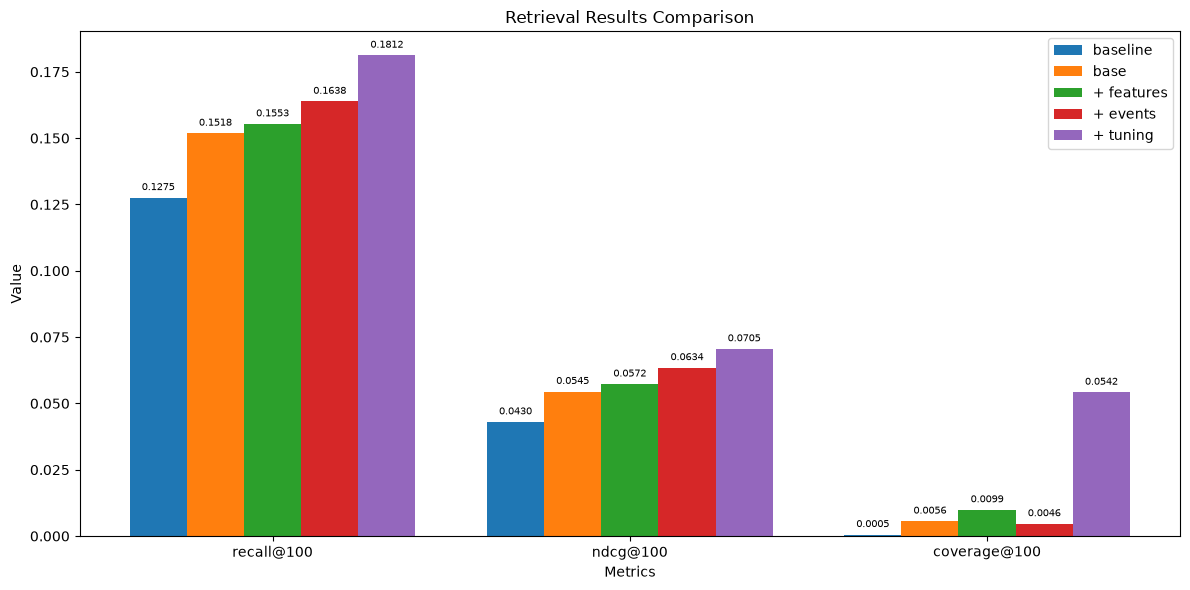

In [18]:
options = list(retrieval_evals.keys())
metrics = ["recall@100", "ndcg@100", "coverage@100"]
x = np.arange(len(metrics))
width = 0.8 / len(options)

fig, ax = plt.subplots(figsize=(12, 6))

for i, option in enumerate(options):
    values = [retrieval_evals[option][m] for m in metrics]
    offset = (i - (len(options) - 1) / 2) * width
    bars = ax.bar(x + offset, values, width, label=option)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=7)

ax.set_xlabel('Metrics')
ax.set_ylabel('Value')
ax.set_title('Retrieval Results Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

plt.tight_layout()
plt.show()

Every model variant has already been inferred above. Let's look at the predictions of the last model to see
their internal structure.

In [113]:
predictions = pl.read_parquet("../retrieval/predictions")
display(predictions.sample(5))

_index,timestamp,client_id,target,context,prediction
u32,datetime[ns],str,list[struct[2]],struct[1],list[struct[2]]
1209,1973-07-21 12:00:00,"""30865387""","[{""nfmcg_18106422"",1}, {""nfmcg_22195491"",1}]",{17},"[{""nfmcg_13647154"",6.183594}, {""nfmcg_19353812"",6.140625}, … {""nfmcg_5666785"",-0.493164}]"
1427,1973-07-22 12:00:00,"""14871034""","[{""nfmcg_6136132"",1}, {""nfmcg_20564139"",1}, {""nfmcg_26631679"",1}]",{0},"[{""nfmcg_10936154"",5.765625}, {""nfmcg_23323118"",5.671875}, … {""nfmcg_18737313"",-0.168457}]"
1004,1973-07-14 12:00:00,"""14931902""","[{""nfmcg_20876365"",1}, {""nfmcg_16311295"",1}]",{10},"[{""nfmcg_6301488"",10.210938}, {""nfmcg_10723941"",10.09375}, … {""nfmcg_9329025"",1.988281}]"
1559,1973-07-29 12:00:00,"""29700841""","[{""nfmcg_20002925"",1}, {""nfmcg_14129567"",1}]",{0},"[{""nfmcg_1388195"",7.160156}, {""nfmcg_6301488"",6.984375}, … {""nfmcg_19617843"",0.828613}]"
552,1973-07-07 12:00:00,"""64379788""","[{""nfmcg_8961427"",1}, {""nfmcg_14380950"",1}]",{9},"[{""nfmcg_21503632"",4.332031}, {""nfmcg_8957656"",4.199219}, … {""nfmcg_5574961"",-0.901855}]"


# Ranking

The next task is reordering a ready-made pool of candidates. In Perseus, ranking is posed as predicting the
probabilities of the target events for each candidate; the final score is their weighted sum, with the weights
set by the ML engineer in the config (`task.head.label_to_weight`).

## Basis

Like retrieval, ranking needs artifacts with items, but the target is more involved. For every item it stores
not only the item itself but also a set of boolean labels — which of the target actions the client performed on
it. In the test fold a relevance is added on top of the labels, and the samples gain a mandatory `items` column:
the candidate pool the model scores and reorders.

We build the basis from all four Marketplace event types over the same 120 days and with the same rounding of
the timestamp to the date. Assume that from the business point of view the events rank as
clickout > like > click > view.

In [17]:
os.makedirs("../ranking/basis/train/artifacts/", exist_ok=True)
os.makedirs("../ranking/basis/test/artifacts/", exist_ok=True)
os.makedirs("../ranking/basis/artifacts/", exist_ok=True)

In [18]:
samples = pl.concat([
    pl.read_parquet("/event-hub/marketplace-clickout").with_columns(pl.lit("clickout").alias("event_type")),
    pl.read_parquet("/event-hub/marketplace-click").with_columns(pl.lit("click").alias("event_type")),
    pl.read_parquet("/event-hub/marketplace-like").with_columns(pl.lit("like").alias("event_type")),
    pl.read_parquet("/event-hub/marketplace-view").with_columns(pl.lit("view").alias("event_type")),
])

start_date = samples["date"].max() - timedelta(days=120)
samples = (
    samples
    .filter(pl.col("timestamp") >= start_date)
    .with_columns((pl.col("date").cast(pl.Datetime) - timedelta(hours=12)).cast(pl.Datetime("ns")).alias("timestamp")).drop("date")
)

print(samples.shape)
display(samples.head(5))

(77278581, 5)


timestamp,client_id,item_id,subdomain,event_type
datetime[ns],str,str,str,str
1973-04-02 12:00:00,"""26735746""","""nfmcg_16852550""","""u2i""","""clickout"""
1973-04-02 12:00:00,"""54801165""","""nfmcg_7530250""","""search""","""clickout"""
1973-04-02 12:00:00,"""54801165""","""nfmcg_25852582""","""search""","""clickout"""
1973-04-02 12:00:00,"""59736422""","""nfmcg_16128172""","""other""","""clickout"""
1973-04-02 12:00:00,"""84839602""","""nfmcg_12780930""","""other""","""clickout"""


In [19]:
samples = samples.with_columns(
    pl.struct([
        pl.col("item_id").alias("item"),
        pl.struct([
            (pl.col("event_type") == "view").alias("view"),
            (pl.col("event_type") == "like").alias("like"),
            (pl.col("event_type") == "click").alias("click"),
            (pl.col("event_type") == "clickout").alias("clickout"),
        ]).alias("labels"),
    ]).alias("target")
).drop("item_id", "event_type")

samples = (
    samples
    .group_by("timestamp", "client_id")
    .agg(pl.col("target").unique())
    .filter(
        pl.col("target").list.eval(
            pl.when(pl.element().struct.field("labels").struct.field("view")).then(0)
            .when(pl.element().struct.field("labels").struct.field("click")).then(1)
            .when(pl.element().struct.field("labels").struct.field("like")).then(2)
            .when(pl.element().struct.field("labels").struct.field("clickout")).then(3)
            .otherwise(-1)
        ).list.unique().list.len() > 1
    )
    .sort("timestamp")
)

print(samples.shape)
display(samples.head(5))

(730015, 3)


timestamp,client_id,target
datetime[ns],str,list[struct[2]]
1973-04-02 12:00:00,"""38468211""","[{""nfmcg_14599123"",{false,false,true,false}}, {""nfmcg_17255757"",{false,false,true,false}}, … {""nfmcg_22388910"",{true,false,false,false}}]"
1973-04-02 12:00:00,"""68577379""","[{""nfmcg_8961427"",{false,false,false,true}}, {""nfmcg_8797298"",{false,false,false,true}}, … {""nfmcg_28388256"",{true,false,false,false}}]"
1973-04-02 12:00:00,"""58468601""","[{""nfmcg_12780930"",{false,false,true,false}}, {""nfmcg_16121034"",{true,false,false,false}}, … {""nfmcg_10798537"",{true,false,false,false}}]"
1973-04-02 12:00:00,"""73471018""","[{""nfmcg_25101378"",{false,false,true,false}}, {""nfmcg_22222683"",{false,false,true,false}}, … {""nfmcg_5311089"",{true,false,false,false}}]"
1973-04-02 12:00:00,"""2417918""","[{""nfmcg_12780930"",{false,false,false,true}}, {""nfmcg_28156205"",{false,false,false,true}}, … {""nfmcg_5407178"",{true,false,false,false}}]"


In [20]:
train_ratio = 0.8
split_idx = int(len(samples) * train_ratio)
split_timestamp = samples["timestamp"][split_idx]

In [21]:
train_samples = samples.filter(pl.col("timestamp") < split_timestamp)

print(train_samples.shape)
display(train_samples.head(5))

(582580, 3)


timestamp,client_id,target
datetime[ns],str,list[struct[2]]
1973-04-02 12:00:00,"""38468211""","[{""nfmcg_14599123"",{false,false,true,false}}, {""nfmcg_17255757"",{false,false,true,false}}, … {""nfmcg_22388910"",{true,false,false,false}}]"
1973-04-02 12:00:00,"""68577379""","[{""nfmcg_8961427"",{false,false,false,true}}, {""nfmcg_8797298"",{false,false,false,true}}, … {""nfmcg_28388256"",{true,false,false,false}}]"
1973-04-02 12:00:00,"""58468601""","[{""nfmcg_12780930"",{false,false,true,false}}, {""nfmcg_16121034"",{true,false,false,false}}, … {""nfmcg_10798537"",{true,false,false,false}}]"
1973-04-02 12:00:00,"""73471018""","[{""nfmcg_25101378"",{false,false,true,false}}, {""nfmcg_22222683"",{false,false,true,false}}, … {""nfmcg_5311089"",{true,false,false,false}}]"
1973-04-02 12:00:00,"""2417918""","[{""nfmcg_12780930"",{false,false,false,true}}, {""nfmcg_28156205"",{false,false,false,true}}, … {""nfmcg_5407178"",{true,false,false,false}}]"


The test fold needs a relevance per item (higher is better): 0 for a view, 1 for a click, 2 for a like and 3 for
a clickout. We keep only samples containing more than one relevance level — if all items are equally good there
is nothing to order and the metric on such a sample is uninformative.

In [22]:
test_samples = samples.filter(pl.col("timestamp") >= split_timestamp)
test_samples = (
    test_samples
    .explode("target")
    .with_columns([
        pl.col("target").struct.field("item").alias("item"),
        pl.col("target").struct.field("labels").struct.field("view").alias("view"),
        pl.col("target").struct.field("labels").struct.field("like").alias("like"),
        pl.col("target").struct.field("labels").struct.field("click").alias("click"),
        pl.col("target").struct.field("labels").struct.field("clickout").alias("clickout"),
    ])
    .with_columns(
        pl.when(pl.col("view")).then(0)
         .when(pl.col("click")).then(1)
         .when(pl.col("like")).then(2)
         .when(pl.col("clickout")).then(3)
         .otherwise(-1)
         .alias("relevance")
    )
    .group_by("timestamp", "client_id", "item")
    .agg([
        pl.col("view").any(),
        pl.col("like").any(),
        pl.col("click").any(),
        pl.col("clickout").any(),
        pl.col("relevance").max()
    ])
    .with_columns(
        pl.struct([
            "item",
            pl.struct(["view", "like", "click", "clickout"]).alias("labels"),
            "relevance"
        ]).alias("target")
    )
    .group_by("timestamp", "client_id")
    .agg([
        pl.col("target"),
        pl.col("item").alias("items")
    ])
)

print(test_samples.shape)
display(test_samples.head(5))

(147435, 4)


timestamp,client_id,target,items
datetime[ns],str,list[struct[3]],list[str]
1973-07-07 12:00:00,"""86916519""","[{""nfmcg_1665832"",{true,false,true,false},1}, {""nfmcg_684875"",{true,false,false,false},0}, … {""nfmcg_21684438"",{true,false,false,false},0}]","[""nfmcg_1665832"", ""nfmcg_684875"", … ""nfmcg_21684438""]"
1973-07-16 12:00:00,"""76913997""","[{""nfmcg_19853263"",{false,true,true,false},2}, {""nfmcg_14285175"",{true,false,false,false},0}, … {""nfmcg_19639666"",{true,false,false,false},0}]","[""nfmcg_19853263"", ""nfmcg_14285175"", … ""nfmcg_19639666""]"
1973-07-25 12:00:00,"""46861815""","[{""nfmcg_15852654"",{true,false,false,false},0}, {""nfmcg_11970100"",{true,false,false,false},0}, … {""nfmcg_23446680"",{true,false,false,false},0}]","[""nfmcg_15852654"", ""nfmcg_11970100"", … ""nfmcg_23446680""]"
1973-07-28 12:00:00,"""69108894""","[{""nfmcg_22089893"",{true,false,false,false},0}, {""nfmcg_24538823"",{true,false,false,false},0}, … {""nfmcg_1374633"",{true,false,false,false},0}]","[""nfmcg_22089893"", ""nfmcg_24538823"", … ""nfmcg_1374633""]"
1973-07-20 12:00:00,"""46698089""","[{""nfmcg_12826101"",{true,false,false,false},0}, {""nfmcg_21306244"",{true,false,false,false},0}, … {""nfmcg_8797298"",{true,false,false,false},0}]","[""nfmcg_12826101"", ""nfmcg_21306244"", … ""nfmcg_8797298""]"


### Context

Same as in retrieval: the socdem cluster goes into the context.

In [23]:
train_samples = train_samples.join(CLIENTS, on="client_id", how="left")
train_samples = train_samples.with_columns(
    pl.struct(["socdem_cluster"]).alias("context")
).drop(["socdem_cluster"])

print(train_samples.shape)
display(train_samples.head(5))

(582580, 4)


timestamp,client_id,target,context
datetime[ns],str,list[struct[2]],struct[1]
1973-04-02 12:00:00,"""38468211""","[{""nfmcg_14599123"",{false,false,true,false}}, {""nfmcg_17255757"",{false,false,true,false}}, … {""nfmcg_22388910"",{true,false,false,false}}]",{20}
1973-04-02 12:00:00,"""68577379""","[{""nfmcg_8961427"",{false,false,false,true}}, {""nfmcg_8797298"",{false,false,false,true}}, … {""nfmcg_28388256"",{true,false,false,false}}]",{4}
1973-04-02 12:00:00,"""58468601""","[{""nfmcg_12780930"",{false,false,true,false}}, {""nfmcg_16121034"",{true,false,false,false}}, … {""nfmcg_10798537"",{true,false,false,false}}]",{5}
1973-04-02 12:00:00,"""73471018""","[{""nfmcg_25101378"",{false,false,true,false}}, {""nfmcg_22222683"",{false,false,true,false}}, … {""nfmcg_5311089"",{true,false,false,false}}]",{17}
1973-04-02 12:00:00,"""2417918""","[{""nfmcg_12780930"",{false,false,false,true}}, {""nfmcg_28156205"",{false,false,false,true}}, … {""nfmcg_5407178"",{true,false,false,false}}]",{0}


In [24]:
test_samples = test_samples.join(CLIENTS, on="client_id", how="left")
test_samples = test_samples.with_columns(
    pl.struct(["socdem_cluster"]).alias("context")
).drop(["socdem_cluster"])

print(test_samples.shape)
display(test_samples.head(5))

(147435, 5)


timestamp,client_id,target,items,context
datetime[ns],str,list[struct[3]],list[str],struct[1]
1973-07-07 12:00:00,"""86916519""","[{""nfmcg_1665832"",{true,false,true,false},1}, {""nfmcg_684875"",{true,false,false,false},0}, … {""nfmcg_21684438"",{true,false,false,false},0}]","[""nfmcg_1665832"", ""nfmcg_684875"", … ""nfmcg_21684438""]",{10}
1973-07-16 12:00:00,"""76913997""","[{""nfmcg_19853263"",{false,true,true,false},2}, {""nfmcg_14285175"",{true,false,false,false},0}, … {""nfmcg_19639666"",{true,false,false,false},0}]","[""nfmcg_19853263"", ""nfmcg_14285175"", … ""nfmcg_19639666""]",{9}
1973-07-25 12:00:00,"""46861815""","[{""nfmcg_15852654"",{true,false,false,false},0}, {""nfmcg_11970100"",{true,false,false,false},0}, … {""nfmcg_23446680"",{true,false,false,false},0}]","[""nfmcg_15852654"", ""nfmcg_11970100"", … ""nfmcg_23446680""]",{9}
1973-07-28 12:00:00,"""69108894""","[{""nfmcg_22089893"",{true,false,false,false},0}, {""nfmcg_24538823"",{true,false,false,false},0}, … {""nfmcg_1374633"",{true,false,false,false},0}]","[""nfmcg_22089893"", ""nfmcg_24538823"", … ""nfmcg_1374633""]",{4}
1973-07-20 12:00:00,"""46698089""","[{""nfmcg_12826101"",{true,false,false,false},0}, {""nfmcg_21306244"",{true,false,false,false},0}, … {""nfmcg_8797298"",{true,false,false,false},0}]","[""nfmcg_12826101"", ""nfmcg_21306244"", … ""nfmcg_8797298""]",{20}


#### Save

In [25]:
train_samples.write_parquet("../ranking/basis/train/samples.pq")
test_samples.write_parquet("../ranking/basis/test/samples.pq")

### Artifacts

Same as in retrieval — the item and its brand.

In [26]:
artifacts = pl.DataFrame(
    train_samples.select(pl.col("target").list.eval(pl.element().struct.field("item")).explode()).unique()
).rename({"target": "item"})
artifacts = artifacts.with_columns(pl.col("item")).join(ITEMS, left_on="item", right_on="item_id", how="left").select("item", "brand_id")

print(artifacts.shape)
display(artifacts.head(5))

(1252116, 2)


item,brand_id
str,u64
"""nfmcg_8018220""",191971
"""nfmcg_28370106""",99232
"""nfmcg_12279911""",47917
"""nfmcg_1410095""",227580
"""nfmcg_26022643""",47917


#### Save

In [27]:
artifacts.write_parquet("../ranking/basis/train/artifacts/items.pq")
artifacts.write_parquet("../ranking/basis/test/artifacts/items.pq")

### Inference basis

The inference basis is a full copy of the test fold, target included: the target is not needed for inference
itself, but we compute the metrics of both the baseline and the model on this same basis, so both are evaluated
on the same set of samples.

The candidate pool is the `items` column of the test fold — each sample's own set of items, the same one the
model was validated on during training. In production the pool would come from a candidate generator, for
example the retrieval model from the previous section; here we measure the quality of the reordering on its own,
so the pool holds the items the user saw that day.

In [28]:
inference_basis = pl.read_parquet("../ranking/basis/test/samples.pq")

print(inference_basis.shape)
display(inference_basis.head(5))

inference_basis.write_parquet("../ranking/basis/samples.pq")

(147435, 5)


timestamp,client_id,target,items,context
datetime[ns],str,list[struct[3]],list[str],struct[1]
1973-07-07 12:00:00,"""86916519""","[{""nfmcg_1665832"",{true,false,true,false},1}, {""nfmcg_684875"",{true,false,false,false},0}, … {""nfmcg_21684438"",{true,false,false,false},0}]","[""nfmcg_1665832"", ""nfmcg_684875"", … ""nfmcg_21684438""]",{10}
1973-07-16 12:00:00,"""76913997""","[{""nfmcg_19853263"",{false,true,true,false},2}, {""nfmcg_14285175"",{true,false,false,false},0}, … {""nfmcg_19639666"",{true,false,false,false},0}]","[""nfmcg_19853263"", ""nfmcg_14285175"", … ""nfmcg_19639666""]",{9}
1973-07-25 12:00:00,"""46861815""","[{""nfmcg_15852654"",{true,false,false,false},0}, {""nfmcg_11970100"",{true,false,false,false},0}, … {""nfmcg_23446680"",{true,false,false,false},0}]","[""nfmcg_15852654"", ""nfmcg_11970100"", … ""nfmcg_23446680""]",{9}
1973-07-28 12:00:00,"""69108894""","[{""nfmcg_22089893"",{true,false,false,false},0}, {""nfmcg_24538823"",{true,false,false,false},0}, … {""nfmcg_1374633"",{true,false,false,false},0}]","[""nfmcg_22089893"", ""nfmcg_24538823"", … ""nfmcg_1374633""]",{4}
1973-07-20 12:00:00,"""46698089""","[{""nfmcg_12826101"",{true,false,false,false},0}, {""nfmcg_21306244"",{true,false,false,false},0}, … {""nfmcg_8797298"",{true,false,false,false},0}]","[""nfmcg_12826101"", ""nfmcg_21306244"", … ""nfmcg_8797298""]",{20}


In [29]:
inference_artifacts = pl.read_parquet("../ranking/basis/test/artifacts/items.pq")

print(inference_artifacts.shape)
display(inference_artifacts.head(5))

inference_artifacts.write_parquet("../ranking/basis/artifacts/items.pq")

(1252116, 2)


item,brand_id
str,u64
"""nfmcg_8018220""",191971
"""nfmcg_28370106""",99232
"""nfmcg_12279911""",47917
"""nfmcg_1410095""",227580
"""nfmcg_26022643""",47917


Splitting the basis into partitions is also done once.

In [30]:
!uv run python -m perseus inference distribute-samples --workdir ../ranking

Installed 9 packages in 7ms                                 
2026-08-20T15:37:33.593535Z [info     ] has 147435 samples for 100 partitions [perseus.api.distribute_samples]


## Baseline

The baseline orders the pool by item popularity in the train part of the basis, counted over the positive
events — click, like and clickout.

**Note:** as in retrieval, the baseline is computed **before** training the model, on the full inference basis,
and is then used to fill the gaps in the model predictions.

In [19]:
RANKING_METRICS = {
    "ndcg@20": {"type": "ndcg_at_k", "params": {"k": 20}},
    "mrr@20": {"type": "mrr_at_k", "params": {"k": 20}},
}

item_to_popularity = dict(
    train_samples.select(pl.col("target").explode()).unnest("target").unnest("labels")
    .filter(pl.col("click") | pl.col("like") | pl.col("clickout"))
    ["item"].value_counts().iter_rows()
)

inference_basis = pl.read_parquet("../ranking/basis/samples.pq")
inference_artifacts = pl.read_parquet("../ranking/basis/artifacts/items.pq")

inference_basis = inference_basis.with_columns(
    baseline_prediction=pl.col("items").list.eval(
        pl.struct(
            item=pl.element(),
            probas=pl.struct(**{label: pl.lit(0.0, pl.Float32) for label in ["view", "click", "like", "clickout"]}),
            score=pl.element().replace_strict(item_to_popularity, default=0).cast(pl.Float32),
        )
    )
)

ranking_results = {}
ranking_results["baseline"] = evaluate(
    "ranking",
    inference_basis.with_columns(prediction=pl.col("baseline_prediction")).drop("baseline_prediction"),
    RANKING_METRICS,
    artifacts=inference_artifacts,
)
ranking_results["baseline"]

{'ndcg@20': 0.48120561242103577, 'mrr@20': 0.43566406152052767}

## Training

The model predicts the probability of each event type for each candidate, and the pool is ordered by a single
score — the weighted sum of those probabilities. By default the weights are equal, i.e. a view contributes as
much as a clickout. Through `label_to_weight` we set the weights equal to the relevances: the score then is the
expected relevance, and views do not inflate it.

The metrics are NDCG@20 and MRR@20.

In [32]:
%%writefile ../ranking/config.yaml
task:
  type: ranking
  head:
    label_to_weight:
      view: 0
      click: 1
      like: 2
      clickout: 3
  metrics:
    ndcg@20:
      type: ndcg_at_k
      params:
        k: 20
    mrr@20:
      type: mrr_at_k
      params:
        k: 20

events:
  marketplace-click:
    attributes:
      item_id:
      subdomain:
    max_duration_per_sequence: 365d
    priority: 1
  marketplace-like:
    attributes:
      item_id:
      subdomain:
    max_duration_per_sequence: 365d
    priority: 2
  marketplace-clickout:
    attributes:
      item_id:
      subdomain:
    max_duration_per_sequence: 365d
    priority: 3
  marketplace-view:
    attributes:
      item_id:
      subdomain:
    max_duration_per_sequence: 365d
    priority: 0

max_events_per_sequence: 512

encoders:
  item:
    type: id
  subdomain:
    type: id
  brand_id:
    type: id
  socdem_cluster:
    type: id

features:
  item_id:
    located_in:
      event: true
    encoder: item
  item:
    located_in:
      artifacts: true
    encoder: item
  subdomain:
    located_in:
      event: true
    encoder: subdomain
  brand_id:
    located_in:
      artifacts: true
    encoder: brand_id
  socdem_cluster:
    located_in:
      context: true
    encoder: socdem_cluster

backbone:
  dim: 256
  history_aggregator:
    type: modern_bert
    params:
      num_layers: 4
      num_heads: 4
      dropout: 0.1
  event_aggregator:
    type: sum
  context_aggregator:
    type: identity

training:
  num_epochs: 10
  log_every_n_train_steps: 1000
  dataloader:
    batch_size: 32
    num_workers: 2
    pin_memory: true
    shuffle: true
  test_dataloader:
    batch_size: 32
    num_workers: 2
    pin_memory: true
  early_stopping:
    metric: ndcg@20
    mode: max
    patience: 3
  optimizer:
    params:
      lr: 0.0003

inference:
  backbone_dataloader:
    batch_size: 64
    num_workers: 0
    pin_memory: true
  head_dataloader:
    batch_size: 64
    num_workers: 0
    pin_memory: true

Writing ../ranking/config.yaml


In [ ]:
!uv run python -m perseus train prepare-dataset --workdir ../ranking

In [ ]:
!uv run accelerate launch -m perseus train fit-model --workdir ../ranking

## Inference

The basis is already split into partitions, so only the embeddings and the predictions are left.

In [ ]:
!uv run python -m perseus inference make-backbone-embeddings --workdir ../ranking
!uv run python -m perseus inference make-head-predictions --workdir ../ranking

The model returns a probability for every event type together with their weighted sum.

In [36]:
predictions = pl.read_parquet("../ranking/predictions")

print(predictions.shape)
display(predictions.sample(5))

(137382, 7)


_index,timestamp,client_id,target,items,context,prediction
u32,datetime[ns],str,list[struct[3]],list[str],struct[1],list[struct[3]]
1240,1973-07-17 12:00:00,"""3893991""","[{""nfmcg_20987893"",{true,false,false,false},0}, {""nfmcg_24216165"",{true,false,false,false},0}, … {""nfmcg_23811922"",{true,false,false,false},0}]","[""nfmcg_20987893"", ""nfmcg_24216165"", … ""nfmcg_23811922""]",{21},"[{""nfmcg_20987893"",{0.678223,0.00068,0.296875,0.019943},0.358065}, {""nfmcg_24216165"",{0.984375,0.000117,0.014229,0.001351},0.018517}, … {""nfmcg_23811922"",{0.941895,0.000175,0.05603,0.002443},0.063711}]"
1215,1973-07-08 12:00:00,"""16735978""","[{""nfmcg_11214271"",{true,false,false,false},0}, {""nfmcg_22082956"",{true,false,false,false},0}, … {""nfmcg_7334916"",{true,false,false,false},0}]","[""nfmcg_11214271"", ""nfmcg_22082956"", … ""nfmcg_7334916""]",{20},"[{""nfmcg_11214271"",{0.874512,0.00358,0.11615,0.006691},0.143383}, {""nfmcg_22082956"",{0.884277,0.001897,0.084778,0.02002},0.14863}, … {""nfmcg_24538853"",{0.875488,0.000833,0.1015625,0.015839},0.150744}]"
952,1973-07-22 12:00:00,"""9965944""","[{""nfmcg_20281832"",{true,false,false,false},0}, {""nfmcg_9638389"",{true,false,false,false},0}, … {""nfmcg_9555015"",{true,false,false,false},0}]","[""nfmcg_20281832"", ""nfmcg_9638389"", … ""nfmcg_9555015""]",{17},"[{""nfmcg_20281832"",{0.959961,0.001069,0.034546,0.004963},0.051573}, {""nfmcg_9638389"",{0.936035,0.001367,0.053314,0.008125},0.080423}, … {""nfmcg_9555015"",{0.919922,0.000675,0.063354,0.010246},0.095443}]"
302,1973-07-06 12:00:00,"""43287786""","[{""nfmcg_20564139"",{true,false,false,false},0}, {""nfmcg_5442207"",{true,false,false,false},0}, … {""nfmcg_19787710"",{true,false,false,false},0}]","[""nfmcg_20564139"", ""nfmcg_5442207"", … ""nfmcg_19787710""]",{20},"[{""nfmcg_20564139"",{0.897461,0.000432,0.103027,0.003124},0.113265}, {""nfmcg_5442207"",{0.940918,0.000538,0.059418,0.001889},0.066161}, … {""nfmcg_19787710"",{0.96582,0.000098,0.034821,0.001147},0.038459}]"
816,1973-07-04 12:00:00,"""27639654""","[{""nfmcg_22211380"",{true,false,false,false},0}, {""nfmcg_6613648"",{true,false,false,false},0}, … {""nfmcg_14079625"",{true,false,false,false},0}]","[""nfmcg_22211380"", ""nfmcg_6613648"", … ""nfmcg_14079625""]",{10},"[{""nfmcg_22211380"",{0.841309,0.000712,0.147217,0.010529},0.180227}, {""nfmcg_6613648"",{0.849609,0.000843,0.125488,0.018341},0.182197}, … {""nfmcg_14079625"",{0.95459,0.000045,0.050995,0.000497},0.052577}]"


The model metrics are computed with the same code as the baseline: join the predictions onto the inference
basis and fill the gaps with the baseline, so both are evaluated on the same set of samples.

In [37]:
predictions = pl.read_parquet("../ranking/predictions").select(
    "client_id",
    pl.col("timestamp").cast(inference_basis.schema["timestamp"]),
    "prediction",
)

ranking_results["model"] = evaluate(
    "ranking",
    inference_basis.join(
        predictions, on=["client_id", "timestamp"], how="left"
    ).with_columns(
        pl.col("prediction").fill_null(pl.col("baseline_prediction"))
    ).drop("baseline_prediction"),
    RANKING_METRICS,
    artifacts=inference_artifacts,
)

display(pl.DataFrame([{"case": case} | metrics for case, metrics in ranking_results.items()]))

case,ndcg@20,mrr@20
str,f64,f64
"""baseline""",0.481206,0.435664
"""model""",0.498396,0.45775


# Classification

We predict whether a user will perform at least one active action (click, like or clickout) in Marketplace
within 7 days after the sample date. The metric is ROC-AUC.

## Basis

The classification basis is as simple as it gets: the target is a string with the class name, and no extra
columns or artifacts are needed.

We build the basis from the days on which the user was active in Marketplace, over the same last 120 days and
with the same rounding of the timestamp.

In [17]:
os.makedirs("../classification/basis/train/", exist_ok=True)
os.makedirs("../classification/basis/test/", exist_ok=True)

In [18]:
samples = pl.concat([
    pl.read_parquet("/event-hub/marketplace-click"),
    pl.read_parquet("/event-hub/marketplace-like"),
    pl.read_parquet("/event-hub/marketplace-clickout"),
]).select("date", "timestamp", "client_id")

start_date = samples["date"].max() - timedelta(days=120)
samples = (
    samples
    .filter(pl.col("timestamp") >= start_date)
    .with_columns((pl.col("date").cast(pl.Datetime) - timedelta(hours=12)).cast(pl.Datetime("ns")).alias("timestamp")).drop("date")
    .unique(["timestamp", "client_id"])
    .sort("client_id", "timestamp")
)

print(samples.shape)
display(samples.head(5))

(794504, 2)


timestamp,client_id
datetime[ns],str
1973-04-29 12:00:00,"""10000154"""
1973-07-01 12:00:00,"""10000154"""
1973-07-02 12:00:00,"""10000154"""
1973-04-10 12:00:00,"""10000256"""
1973-05-17 12:00:00,"""10000256"""


The target is computed over the window (t, t + 7 days], i.e. strictly in the future relative to the sample:
`visit` if there was any activity in the window and `no_visit` otherwise. The last 7 days of the sample are
dropped — their window is incomplete and the target would be understated.

In [19]:
horizon = timedelta(days=7)

next_week_visits = samples.rolling(
    index_column="timestamp",
    period="7d",
    offset="0d",
    closed="right",
    group_by="client_id",
).agg(pl.len().alias("num_visits"))

samples = (
    samples
    .filter(pl.col("timestamp") < pl.col("timestamp").max() - horizon)
    .join(next_week_visits, on=["client_id", "timestamp"], how="left")
    .select(
        "timestamp",
        "client_id",
        pl.when(pl.col("num_visits") > 0).then(pl.lit("visit")).otherwise(pl.lit("no_visit")).alias("target"),
    )
    .sort("timestamp")
)

print(samples.shape)
display(samples.head(5))

(768984, 3)


timestamp,client_id,target
datetime[ns],str,str
1973-04-02 12:00:00,"""10012526""","""no_visit"""
1973-04-02 12:00:00,"""10013518""","""no_visit"""
1973-04-02 12:00:00,"""10015606""","""no_visit"""
1973-04-02 12:00:00,"""10041257""","""no_visit"""
1973-04-02 12:00:00,"""1004509""","""no_visit"""


Let's look at the class balance.

In [20]:
display(samples["target"].value_counts(normalize=True))

target,proportion
str,f64
"""no_visit""",0.708865
"""visit""",0.291135


Split the basis into train and test 80/20 by time.

In [21]:
train_ratio = 0.8
split_idx = int(len(samples) * train_ratio)
split_timestamp = samples["timestamp"][split_idx]

In [22]:
train_samples = samples.filter(pl.col("timestamp") < split_timestamp)

print(train_samples.shape)
display(train_samples.head(5))

(610609, 3)


timestamp,client_id,target
datetime[ns],str,str
1973-04-02 12:00:00,"""10012526""","""no_visit"""
1973-04-02 12:00:00,"""10013518""","""no_visit"""
1973-04-02 12:00:00,"""10015606""","""no_visit"""
1973-04-02 12:00:00,"""10041257""","""no_visit"""
1973-04-02 12:00:00,"""1004509""","""no_visit"""


In [23]:
test_samples = samples.filter(pl.col("timestamp") >= split_timestamp)

print(test_samples.shape)
display(test_samples.head(5))

(158375, 3)


timestamp,client_id,target
datetime[ns],str,str
1973-06-29 12:00:00,"""10000932""","""no_visit"""
1973-06-29 12:00:00,"""10006600""","""visit"""
1973-06-29 12:00:00,"""10027248""","""no_visit"""
1973-06-29 12:00:00,"""10029787""","""no_visit"""
1973-06-29 12:00:00,"""10036106""","""visit"""


### Context

Same as before: the socdem cluster goes into the context.

In [24]:
train_samples = train_samples.join(CLIENTS, on="client_id", how="left")
train_samples = train_samples.with_columns(
    pl.struct(["socdem_cluster"]).alias("context")
).drop(["socdem_cluster"])

print(train_samples.shape)
display(train_samples.head(5))

(610609, 4)


timestamp,client_id,target,context
datetime[ns],str,str,struct[1]
1973-04-02 12:00:00,"""10012526""","""no_visit""",{17}
1973-04-02 12:00:00,"""10013518""","""no_visit""",{7}
1973-04-02 12:00:00,"""10015606""","""no_visit""",{17}
1973-04-02 12:00:00,"""10041257""","""no_visit""",{20}
1973-04-02 12:00:00,"""1004509""","""no_visit""",{9}


In [25]:
test_samples = test_samples.join(CLIENTS, on="client_id", how="left")
test_samples = test_samples.with_columns(
    pl.struct(["socdem_cluster"]).alias("context")
).drop(["socdem_cluster"])

print(test_samples.shape)
display(test_samples.head(5))

(158375, 4)


timestamp,client_id,target,context
datetime[ns],str,str,struct[1]
1973-06-29 12:00:00,"""10000932""","""no_visit""",{19}
1973-06-29 12:00:00,"""10006600""","""visit""",{10}
1973-06-29 12:00:00,"""10027248""","""no_visit""",{20}
1973-06-29 12:00:00,"""10029787""","""no_visit""",{17}
1973-06-29 12:00:00,"""10036106""","""visit""",{9}


#### Save

In [26]:
train_samples.write_parquet("../classification/basis/train/samples.pq")
test_samples.write_parquet("../classification/basis/test/samples.pq")

### Inference basis

The inference basis is a full copy of the test fold, target included. Artifacts are not needed here — the model
predicts the class distribution straight from the client embedding. We prepare the basis once, before the
baseline and before training.

In [27]:
inference_basis = pl.read_parquet("../classification/basis/test/samples.pq")

print(inference_basis.shape)
display(inference_basis.head(5))

inference_basis.write_parquet("../classification/basis/samples.pq")

(158375, 4)


timestamp,client_id,target,context
datetime[ns],str,str,struct[1]
1973-06-29 12:00:00,"""10000932""","""no_visit""",{19}
1973-06-29 12:00:00,"""10006600""","""visit""",{10}
1973-06-29 12:00:00,"""10027248""","""no_visit""",{20}
1973-06-29 12:00:00,"""10029787""","""no_visit""",{17}
1973-06-29 12:00:00,"""10036106""","""visit""",{9}


In [ ]:
!uv run python -m perseus inference distribute-samples --workdir ../classification

## Baseline

The baseline predicts `visit` if the client had at least one positive interaction in the 30-day window prior to the timestamp, otherwise `no_visit`.

**Note:** as before, the baseline is computed **before** training the model, on the full inference basis, and is
then used to fill the gaps in the model predictions.

In [42]:
CLASSIFICATION_METRICS = {
  "roc_auc": {"type": "roc_auc", "params": {"pos_label": "visit"}},
}

visit_rate = (train_samples["target"] == "visit").mean()
baseline_prediction = pl.struct(
  no_visit=pl.lit(1 - visit_rate, pl.Float32),
  visit=pl.lit(visit_rate, pl.Float32),
)

inference_basis = pl.read_parquet("../classification/basis/samples.pq")

activity = pl.concat([train_samples, test_samples]).select("client_id", "timestamp").sort("client_id", "timestamp")

visited_before = activity.join(
  activity.rolling(
      index_column="timestamp",
      period="7d",
      offset="-30d",
      closed="left",
      group_by="client_id",
  ).agg(pl.len().alias("num_prior_visits")),
  on=["client_id", "timestamp"],
  how="left",
).with_columns(
  (pl.col("num_prior_visits").fill_null(0) > 0).cast(pl.Float32).alias("visit")
).select("client_id", "timestamp", "visit")

classification_results = {}
classification_results["baseline"] = evaluate(
  "classification",
  inference_basis
  .join(visited_before, on=["client_id", "timestamp"], how="left")
  .with_columns(pl.col("visit").fill_null(0.0))
  .select(
      *inference_basis.columns,
      prediction=pl.struct(
          no_visit=(1 - pl.col("visit")).cast(pl.Float32),
          visit=pl.col("visit"),
      ),
  ),
  CLASSIFICATION_METRICS,
)
classification_results["baseline"]

{'roc_auc': 0.5254057008814689}

## Training

The config is simpler than in the previous tasks: no artifacts are needed, and the model predicts the class
distribution straight from the client embedding. For ROC-AUC in the binary case `pos_label` must be given.

In [43]:
%%writefile ../classification/config.yaml
task:
  type: classification
  metrics:
    roc_auc:
      params:
        pos_label: visit

events:
  marketplace-click:
    attributes:
      item_id:
      subdomain:
    max_duration_per_sequence: 365d
    priority: 2
  marketplace-like:
    attributes:
      item_id:
      subdomain:
    max_duration_per_sequence: 365d
    priority: 1
  marketplace-clickout:
    attributes:
      item_id:
      subdomain:
    max_duration_per_sequence: 365d
    priority: 1
  retail-order:
    max_duration_per_sequence: 365d
  offers-click:
    attributes:
      brand_id:
    max_duration_per_sequence: 365d
  offers-like:
    attributes:
      brand_id:
    max_duration_per_sequence: 365d
  offers-clickout:
    attributes:
      brand_id:
    max_duration_per_sequence: 365d
max_events_per_sequence: 512

encoders:
  item:
    type: id
  subdomain:
    type: id
  brand_id:
    type: id
  socdem_cluster:
    type: id

features:
  item_id:
    located_in:
      event: true
    encoder: item
  subdomain:
    located_in:
      event: true
    encoder: subdomain
  brand_id:
    located_in:
      event: true
    encoder: brand_id
  socdem_cluster:
    located_in:
      context: true
    encoder: socdem_cluster

backbone:
  dim: 256
  history_aggregator:
    type: modern_bert
    params:
      num_layers: 4
      num_heads: 4
      dropout: 0.1
  event_aggregator:
    type: sum
  context_aggregator:
    type: identity

training:
  num_epochs: 10
  log_every_n_train_steps: 1000
  dataloader:
    batch_size: 32
    num_workers: 2
    pin_memory: true
    shuffle: true
  test_dataloader:
    batch_size: 32
    num_workers: 2
    pin_memory: true
  early_stopping:
    metric: roc_auc
    mode: max
    patience: 3
  optimizer:
    params:
      lr: 0.0003

inference:
  backbone_dataloader:
    batch_size: 64
    num_workers: 0
    pin_memory: true
  head_dataloader:
    batch_size: 64
    num_workers: 0
    pin_memory: true

Writing ../classification/config.yaml


The training and inference commands do not change.

In [ ]:
!uv run python -m perseus train prepare-dataset --workdir ../classification

In [ ]:
!uv run accelerate launch -m perseus train fit-model --workdir ../classification

## Inference

In [ ]:
!uv run python -m perseus inference make-backbone-embeddings --workdir ../classification
!uv run python -m perseus inference make-head-predictions --workdir ../classification

The model returns a probability for every class.

In [47]:
predictions = pl.read_parquet("../classification/predictions")

print(predictions.shape)
display(predictions.sample(5))

(135925, 6)


_index,timestamp,client_id,target,context,prediction
u32,datetime[ns],str,str,struct[1],struct[2]
1258,1973-07-14 12:00:00,"""78680477""","""no_visit""",{20},"{0.664214,0.335786}"
987,1973-07-11 12:00:00,"""72995280""","""visit""",{7},"{0.696681,0.303319}"
1457,1973-07-20 12:00:00,"""36010682""","""no_visit""",{5},"{0.791176,0.208824}"
603,1973-07-06 12:00:00,"""52584283""","""no_visit""",{20},"{0.661486,0.338514}"
642,1973-07-06 12:00:00,"""79564406""","""no_visit""",{18},"{0.801936,0.198064}"


The model metrics are computed with the same code as the baseline, over the probability of the `visit` class:
join the predictions onto the inference basis and fill the gaps with the baseline.

In [48]:
predictions = pl.read_parquet("../classification/predictions").select(
    "client_id",
    pl.col("timestamp").cast(inference_basis.schema["timestamp"]),
    "prediction",
)

classification_results["model"] = evaluate(
    "classification",
    inference_basis.join(
        predictions, on=["client_id", "timestamp"], how="left"
    ).with_columns(
        pl.col("prediction").fill_null(baseline_prediction)
    ),
    CLASSIFICATION_METRICS,
)

display(pl.DataFrame([{"case": case} | metrics for case, metrics in classification_results.items()]))

case,roc_auc
str,f64
"""baseline""",0.525406
"""model""",0.590389


# Regression

The last task is regression. We predict the total price of the items a user will interact with positively in
Marketplace over the next month. Views are excluded, since a view is not a positive interaction. The metrics are
MAE and RMSE.

## Basis

The basis is built the same way as for classification, but this time we need the items themselves and their
price, so events are deduplicated down to (date, user) pairs only after the join with the item table.

In [16]:
os.makedirs("../regression/basis/train/", exist_ok=True)
os.makedirs("../regression/basis/test/", exist_ok=True)

In [17]:
events = pl.concat([
    pl.read_parquet("/event-hub/marketplace-click"),
    pl.read_parquet("/event-hub/marketplace-like"),
    pl.read_parquet("/event-hub/marketplace-clickout"),
]).select("date", "timestamp", "client_id", "item_id")

start_date = events["date"].max() - timedelta(days=120)
events = (
    events
    .filter(pl.col("timestamp") >= start_date)
    .with_columns((pl.col("date").cast(pl.Datetime) - timedelta(hours=12)).cast(pl.Datetime("ns")).alias("timestamp")).drop("date")
    .unique(["timestamp", "client_id", "item_id"])
    .join(ITEMS.select("item_id", pl.col("price").cast(pl.Float64)), on="item_id", how="left")
)

print(events.shape)
display(events.head(5))

(2156396, 4)


timestamp,client_id,item_id,price
datetime[ns],str,str,f64
1973-07-21 12:00:00,"""54049740""","""nfmcg_5364203""",2.23019
1973-04-14 12:00:00,"""80802574""","""nfmcg_14599123""",0.800378
1973-04-15 12:00:00,"""84993916""","""nfmcg_3797627""",6.374533
1973-04-28 12:00:00,"""87161855""","""nfmcg_3972373""",0.576628
1973-07-04 12:00:00,"""37823536""","""nfmcg_24183196""",6.211437


We collapse the events into the basket value per day and sum it over the window (t, t + 30 days] — strictly in
the future relative to the sample. The last month of the sample is dropped as incomplete.

In [18]:
horizon = timedelta(days=30)

samples = (
    events
    .group_by("timestamp", "client_id")
    .agg(pl.col("price").sum().alias("daily_spend"))
    .sort("client_id", "timestamp")
)

next_month_spend = samples.rolling(
    index_column="timestamp",
    period="30d",
    offset="0d",
    closed="right",
    group_by="client_id",
).agg(pl.col("daily_spend").sum().alias("target"))

samples = (
    samples
    .filter(pl.col("timestamp") < pl.col("timestamp").max() - horizon)
    .join(next_month_spend, on=["client_id", "timestamp"], how="left")
    .select("timestamp", "client_id", pl.col("target").fill_null(0.0))
    .sort("timestamp")
)

print(samples.shape)
display(samples.head(5))

(626369, 3)


timestamp,client_id,target
datetime[ns],str,f64
1973-04-02 12:00:00,"""10012526""",0.0
1973-04-02 12:00:00,"""10013518""",0.0
1973-04-02 12:00:00,"""10015606""",7.999482
1973-04-02 12:00:00,"""10041257""",0.0
1973-04-02 12:00:00,"""1004509""",0.0


Split the basis into train and test 80/20 by time.

In [19]:
train_ratio = 0.8
split_idx = int(len(samples) * train_ratio)
split_timestamp = samples["timestamp"][split_idx]

In [20]:
train_samples = samples.filter(pl.col("timestamp") < split_timestamp)

print(train_samples.shape)
display(train_samples.head(5))

(497900, 3)


timestamp,client_id,target
datetime[ns],str,f64
1973-04-02 12:00:00,"""10012526""",0.0
1973-04-02 12:00:00,"""10013518""",0.0
1973-04-02 12:00:00,"""10015606""",7.999482
1973-04-02 12:00:00,"""10041257""",0.0
1973-04-02 12:00:00,"""1004509""",0.0


In [21]:
test_samples = samples.filter(pl.col("timestamp") >= split_timestamp)

print(test_samples.shape)
display(test_samples.head(5))

(128469, 3)


timestamp,client_id,target
datetime[ns],str,f64
1973-06-14 12:00:00,"""10014214""",20.272474
1973-06-14 12:00:00,"""10025516""",1.352239
1973-06-14 12:00:00,"""10036025""",2.516834
1973-06-14 12:00:00,"""10040888""",22.687616
1973-06-14 12:00:00,"""10053304""",1.947144


### Context

Same as before: the socdem cluster goes into the context.

In [22]:
train_samples = train_samples.join(CLIENTS, on="client_id", how="left")
train_samples = train_samples.with_columns(
    pl.struct(["socdem_cluster"]).alias("context")
).drop(["socdem_cluster"])

print(train_samples.shape)
display(train_samples.head(5))

(497900, 4)


timestamp,client_id,target,context
datetime[ns],str,f64,struct[1]
1973-04-02 12:00:00,"""10012526""",0.0,{17}
1973-04-02 12:00:00,"""10013518""",0.0,{7}
1973-04-02 12:00:00,"""10015606""",7.999482,{17}
1973-04-02 12:00:00,"""10041257""",0.0,{20}
1973-04-02 12:00:00,"""1004509""",0.0,{9}


In [23]:
test_samples = test_samples.join(CLIENTS, on="client_id", how="left")
test_samples = test_samples.with_columns(
    pl.struct(["socdem_cluster"]).alias("context")
).drop(["socdem_cluster"])

print(test_samples.shape)
display(test_samples.head(5))

(128469, 4)


timestamp,client_id,target,context
datetime[ns],str,f64,struct[1]
1973-06-14 12:00:00,"""10014214""",20.272474,{10}
1973-06-14 12:00:00,"""10025516""",1.352239,{1}
1973-06-14 12:00:00,"""10036025""",2.516834,{9}
1973-06-14 12:00:00,"""10040888""",22.687616,{20}
1973-06-14 12:00:00,"""10053304""",1.947144,{9}


#### Save

In [24]:
train_samples.write_parquet("../regression/basis/train/samples.pq")
test_samples.write_parquet("../regression/basis/test/samples.pq")

### Inference basis

The inference basis is a full copy of the test fold, target included. We prepare it once, before the baseline
and before training.

In [25]:
inference_basis = pl.read_parquet("../regression/basis/test/samples.pq")

print(inference_basis.shape)
display(inference_basis.head(5))

inference_basis.write_parquet("../regression/basis/samples.pq")

(128469, 4)


timestamp,client_id,target,context
datetime[ns],str,f64,struct[1]
1973-06-14 12:00:00,"""10014214""",20.272474,{10}
1973-06-14 12:00:00,"""10025516""",1.352239,{1}
1973-06-14 12:00:00,"""10036025""",2.516834,{9}
1973-06-14 12:00:00,"""10040888""",22.687616,{20}
1973-06-14 12:00:00,"""10053304""",1.947144,{9}


In [ ]:
!uv run python -m perseus inference distribute-samples --workdir ../regression

## Baseline

The baseline is a constant prediction — the mean of the train part of the basis.

**Note:** as before, the baseline is computed **before** training the model, on the full inference basis, and is
then used to fill the gaps in the model predictions.

In [27]:
REGRESSION_METRICS = {
    "mae": {"type": "mae"},
    "rmse": {"type": "rmse"},
}

mean_target = train_samples["target"].mean()
baseline_prediction = pl.lit(mean_target, pl.Float32)

inference_basis = pl.read_parquet("../regression/basis/samples.pq")

regression_results = {}
regression_results["baseline"] = evaluate(
    "regression",
    inference_basis.with_columns(prediction=baseline_prediction),
    REGRESSION_METRICS,
)
regression_results["baseline"]

{'mae': 7.759149017568359, 'rmse': 13.935739294057944}

## Training

The config almost repeats the classification one: the task type, the metrics and the head change.

In [37]:
%%writefile ../regression/config.yaml
task:
  type: regression
  metrics:
    mae:
    rmse:
  preprocessor:
    scaler: minmax

events:
  marketplace-click:
    attributes:
      item_id:
      subdomain:
    max_duration_per_sequence: 365d
    priority: 2
  marketplace-like:
    attributes:
      item_id:
      subdomain:
    max_duration_per_sequence: 365d
    priority: 1
  marketplace-clickout:
    attributes:
      item_id:
      subdomain:
    max_duration_per_sequence: 365d
    priority: 1
  retail-order:
    max_duration_per_sequence: 365d
  offers-click:
    attributes:
      brand_id:
    max_duration_per_sequence: 365d
  offers-like:
    attributes:
      brand_id:
    max_duration_per_sequence: 365d
  offers-clickout:
    attributes:
      brand_id:
    max_duration_per_sequence: 365d
max_events_per_sequence: 512

encoders:
  item:
    type: id
  subdomain:
    type: id
  brand_id:
    type: id
  socdem_cluster:
    type: id

features:
  item_id:
    located_in:
      event: true
    encoder: item
  subdomain:
    located_in:
      event: true
    encoder: subdomain
  brand_id:
    located_in:
      event: true
    encoder: brand_id
  socdem_cluster:
    located_in:
      context: true
    encoder: socdem_cluster

backbone:
  dim: 256
  history_aggregator:
    type: modern_bert
    params:
      num_layers: 4
      num_heads: 4
      dropout: 0.1
  event_aggregator:
    type: sum
  context_aggregator:
    type: identity

training:
  num_epochs: 10
  log_every_n_train_steps: 1000
  dataloader:
    batch_size: 32
    num_workers: 2
    pin_memory: true
    shuffle: true
  test_dataloader:
    batch_size: 32
    num_workers: 2
    pin_memory: true
  early_stopping:
    metric: rmse
    mode: min
    patience: 3
  optimizer:
    params:
      lr: 0.0003

inference:
  backbone_dataloader:
    batch_size: 64
    num_workers: 0
    pin_memory: true
  head_dataloader:
    batch_size: 64
    num_workers: 0
    pin_memory: true

Overwriting ../regression/config.yaml


The commands are the same again.

In [ ]:
!uv run python -m perseus train prepare-dataset --workdir ../regression

In [ ]:
!uv run accelerate launch -m perseus train fit-model --workdir ../regression

## Inference

In [ ]:
!uv run python -m perseus inference make-backbone-embeddings --workdir ../regression
!uv run python -m perseus inference make-head-predictions --workdir ../regression

The model returns a single number per user.

In [41]:
predictions = pl.read_parquet("../regression/predictions")

print(predictions.shape)
display(predictions.sample(5))

(108801, 6)


_index,timestamp,client_id,target,context,prediction
u32,datetime[ns],str,f64,struct[1],f32
1001,1973-06-27 12:00:00,"""48179275""",-2.900163,{9},3.155154
987,1973-06-26 12:00:00,"""8182733""",0.0,{12},6.597804
28,1973-06-14 12:00:00,"""4208831""",0.0,{5},4.662041
1244,1973-06-30 12:00:00,"""37475992""",2.802832,{4},4.949821
899,1973-06-25 12:00:00,"""71994191""",0.0,{9},2.594496


The model metrics are computed with the same code as the baseline: join the predictions onto the inference basis
and fill the gaps with the baseline.

In [42]:
predictions = pl.read_parquet("../regression/predictions").select(
    "client_id",
    pl.col("timestamp").cast(inference_basis.schema["timestamp"]),
    "prediction",
)

regression_results["model"] = evaluate(
    "regression",
    inference_basis.join(
        predictions, on=["client_id", "timestamp"], how="left"
    ).with_columns(
        pl.col("prediction").fill_null(baseline_prediction)
    ),
    REGRESSION_METRICS,
)

display(pl.DataFrame([{"case": case} | metrics for case, metrics in regression_results.items()]))

case,mae,rmse
str,f64,f64
"""baseline""",7.759149,13.935739
"""model""",7.149675,13.517492


# Conclusion

Perseus builds a user representation efficiently and solves a range of ML tasks on top of it. The framework is
easy to configure and scales both with the volume of the data and with its variety.